In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [18]:
pd.read_csv('C:/Users/PC/OneDrive/Projeto_Final/manutencao_preditiva.csv')

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


In [19]:
df = pd.read_csv('C:/Users/PC/OneDrive/Projeto_Final/manutencao_preditiva.csv', sep=',')


In [20]:
df.head(5)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [21]:
print('***Informações do DataFrame***')
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')

***Informações do DataFrame***
Número de linhas: 10000
Número de colunas: 14


In [22]:
print('\n***Informações sobre os tipos de dados das variáveis***')
df.dtypes


***Informações sobre os tipos de dados das variáveis***


udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

In [23]:
print('***Resumo estatístico das colunas numéricas***')
df.describe()

***Resumo estatístico das colunas numéricas***


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# Gráfico 1: Histograma de Distribuiçao das Variáveis Preditoras

In [24]:
df.columns

Index(['udi', 'id_produto', 'tipo', 'temperatura_ar_k',
       'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
       'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf',
       'falha_pwf', 'falha_osf', 'falha_rnf'],
      dtype='str')

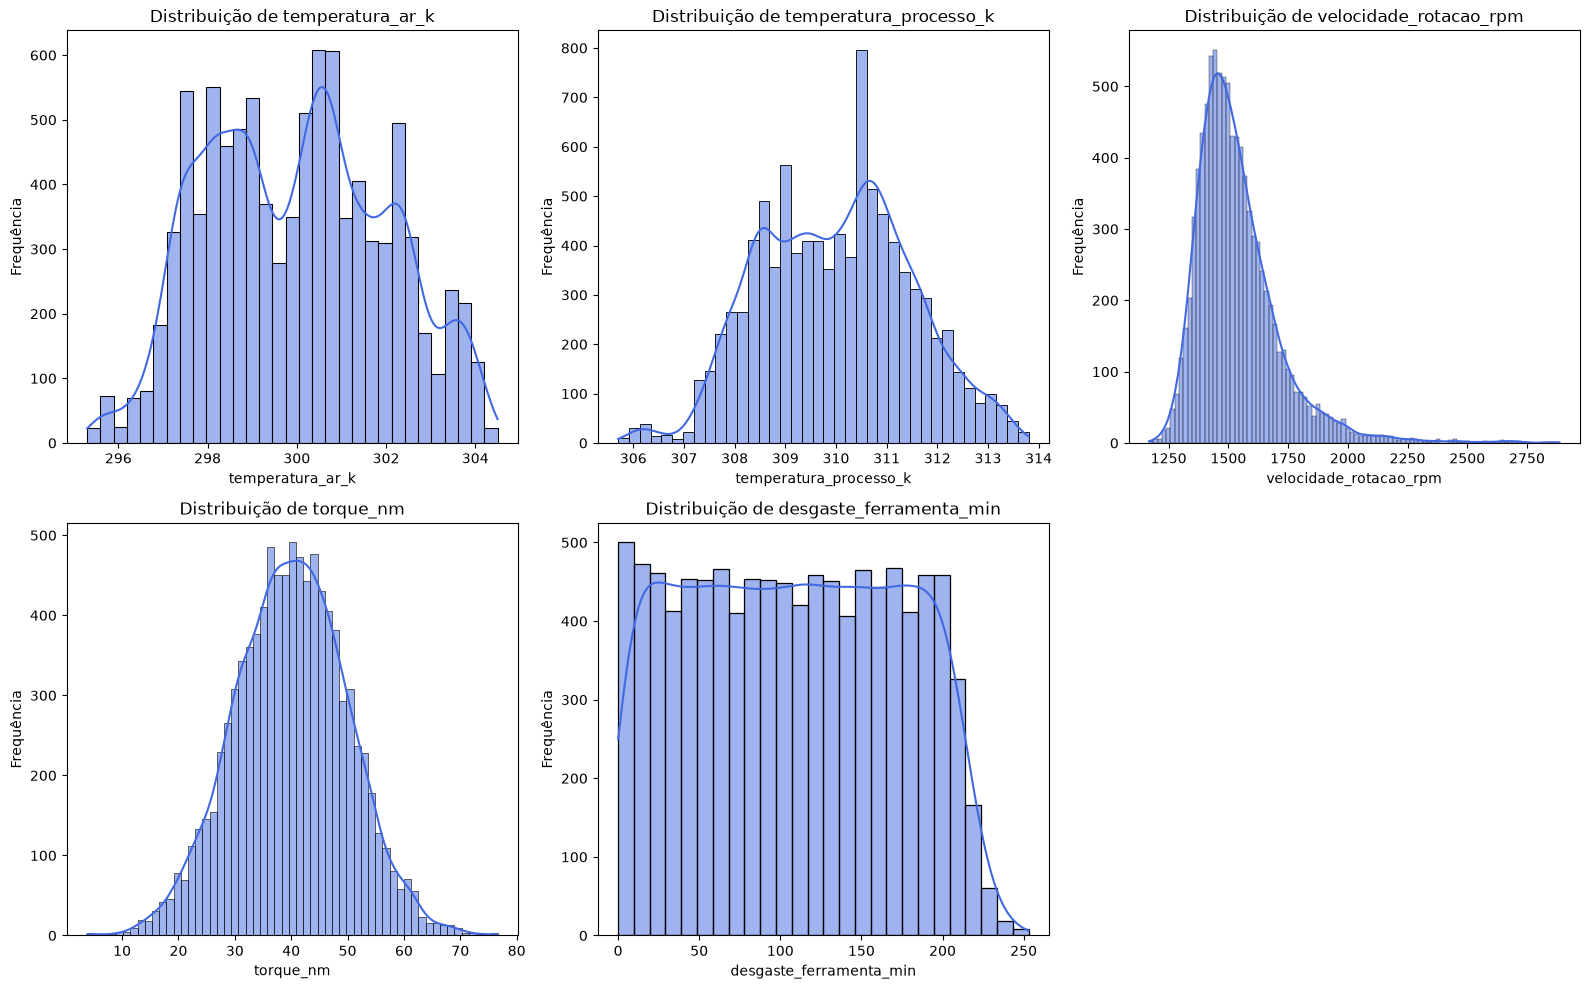

In [25]:
colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=coluna, kde=True, color='royalblue')
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('distribuicao_sensores.png', dpi=300, bbox_inches='tight')
plt.show()

O histograma apresenta a distribuição das principais variáveis monitoradas pelos sensores da máquina. Observa-se a frequência com que determinados valores de temperatura, velocidade de rotação, torque e desgaste da ferramenta ocorrem na base de dados. Essa análise permite identificar a concentração dos valores, possíveis assimetrias, dispersões e indícios de valores extremos, fornecendo uma visão inicial da qualidade dos dados e do comportamento das variáveis que serão utilizadas para prever falhas mecânicas. Essas informações auxiliam na escolha das técnicas de pré-processamento e na construção de modelos de classificação mais adequados.

# Gráfico 1: Countplot das Variáveis alvo

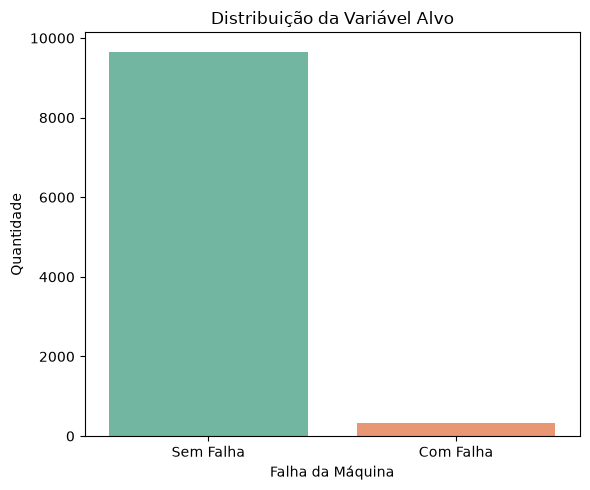

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='falha_maquina',
    hue='falha_maquina',
    palette='Set2',
    legend=False
)

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Falha da Máquina')
plt.ylabel('Quantidade')

plt.xticks(
    [0,1],
    ['Sem Falha','Com Falha']
)

plt.tight_layout()
plt.savefig("02_balanceamento.png", dpi=300)
plt.show()


In [27]:
(df['falha_maquina']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64

96,61% dos registros representam máquinas em funcionamento normal (falha_maquina = 0).
3,39% dos registros representam máquinas que apresentaram falha (falha_maquina = 1).

# Gráfico 1: Heatmap Mapa de calor da correlação

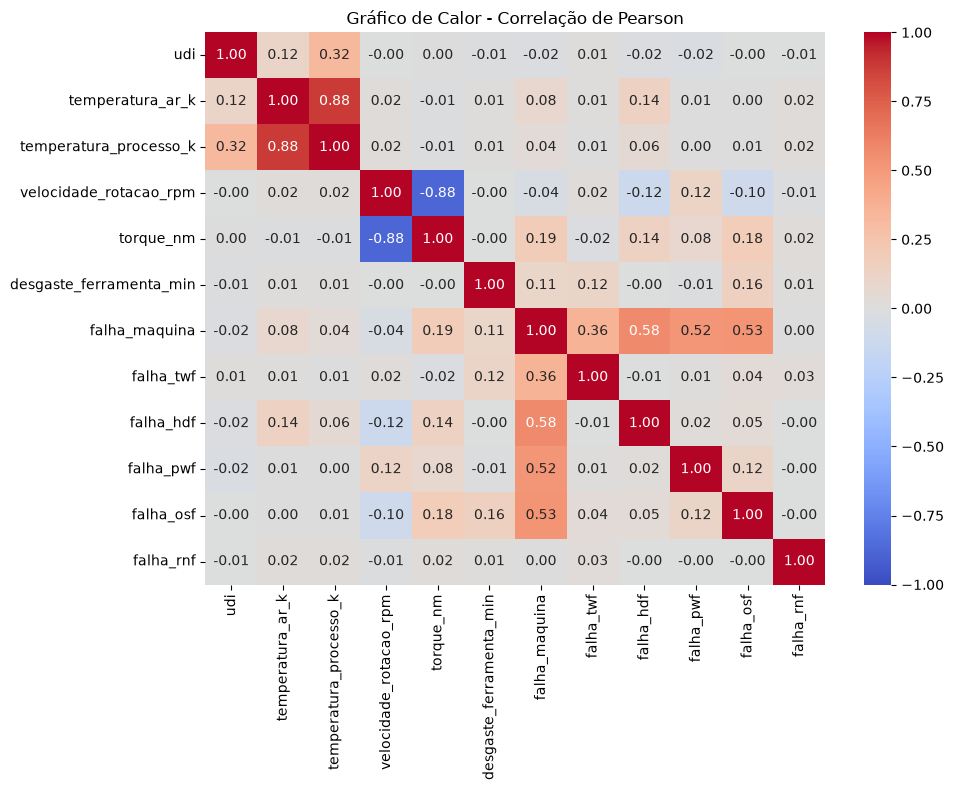

In [28]:
# Calcula a matriz de correlação de Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)
# Desenha o gráfico de calor 
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, 
vmax=1) 
plt.title('Gráfico de Calor - Correlação de Pearson') 
plt.tight_layout()
plt.savefig("03_heatmap.png", dpi=300)
plt.show()

🔴 Vermelho → correlação positiva.
🔵 Azul → correlação negativa.
⚪ Próximo do branco → correlação próxima de zero.